# Step 2-3: 부트스트래핑 패턴 분석

## 배경
- MovieLens v3(2003~2014)에서는 신규 유저에게 시스템 진입 전 **15개 영화 평가**를 요구
- 부트스트래핑용 영화는 인기도 기준 선택 (Top 50~150 **제외**, 중상위 인기작 노출)
- 이 "강제 평점"이 데이터에 어떤 흔적을 남겼는지 확인

## 분석 목표
1. 첫 15개 상호작용의 시간 간격 분석
2. 첫 15개 vs 이후 상호작용의 시간 간격 비교
3. 첫 15개 상호작용의 아이템 인기도 분석
4. 첫 15개 상호작용의 아이템 중복률 분석
5. (선택) v4 시기 유저와 비교

In [1]:
import pandas as pd
import numpy as np
import os
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = '../data/train/'
print("Setup complete.")

Setup complete.


In [2]:
# 데이터 로드
ratings = pd.read_csv(os.path.join(DATA_PATH, 'train_ratings.csv'))
ratings['datetime'] = pd.to_datetime(ratings['time'], unit='s')

# 유저별 시간순 정렬
ratings = ratings.sort_values(['user', 'time']).reset_index(drop=True)

# 유저별 시퀀스 번호 부여 (1부터 시작)
ratings['seq_num'] = ratings.groupby('user').cumcount() + 1

# 아이템 인기도 계산 (전체 상호작용 수 기준)
item_popularity = ratings['item'].value_counts().to_dict()
ratings['item_popularity'] = ratings['item'].map(item_popularity)

# 아이템 인기도 순위
item_rank = ratings['item'].value_counts().rank(ascending=False, method='min').to_dict()
ratings['item_rank'] = ratings['item'].map(item_rank)

print(f"데이터 로드 완료: {len(ratings):,}개 상호작용")
print(f"유저 수: {ratings['user'].nunique():,}")
print(f"아이템 수: {ratings['item'].nunique():,}")

데이터 로드 완료: 5,154,471개 상호작용
유저 수: 31,360
아이템 수: 6,807


In [3]:
# v3 vs v4 시기 구분 (v4 출시: 2014년 11월)
V4_RELEASE = pd.Timestamp('2014-11-01')

# 유저별 첫 활동 시점
user_first_activity = ratings.groupby('user')['datetime'].min()

# v3 시기 유저 vs v4 시기 유저
v3_users = user_first_activity[user_first_activity < V4_RELEASE].index
v4_users = user_first_activity[user_first_activity >= V4_RELEASE].index

print(f"v3 시기 유저 (2014.11 이전 시작): {len(v3_users):,}명")
print(f"v4 시기 유저 (2014.11 이후 시작): {len(v4_users):,}명")

v3 시기 유저 (2014.11 이전 시작): 30,156명
v4 시기 유저 (2014.11 이후 시작): 1,204명


---
## 1. 첫 15개 상호작용의 시간 간격 분석

In [4]:
# 유저별 상호작용 간 시간 간격 계산
ratings['time_diff'] = ratings.groupby('user')['time'].diff()

# 첫 15개 상호작용 (seq_num 1~15)
first_15 = ratings[ratings['seq_num'] <= 15].copy()
# 16번째 이후 상호작용
after_15 = ratings[ratings['seq_num'] > 15].copy()

print(f"첫 15개 상호작용: {len(first_15):,}개")
print(f"16번째 이후 상호작용: {len(after_15):,}개")

첫 15개 상호작용: 470,400개
16번째 이후 상호작용: 4,684,071개


In [5]:
# 첫 15개 내 시간 간격 분포 (seq_num 2~15의 time_diff)
first_15_intervals = first_15[first_15['seq_num'] > 1]['time_diff'].dropna()

print("=" * 60)
print("[첫 15개 상호작용 내 시간 간격 (초)]")
print(f"평균: {first_15_intervals.mean():.1f}초 ({first_15_intervals.mean()/60:.1f}분)")
print(f"중앙값: {first_15_intervals.median():.1f}초 ({first_15_intervals.median()/60:.1f}분)")
print(f"최소: {first_15_intervals.min():.1f}초")
print(f"최대: {first_15_intervals.max():.1f}초 ({first_15_intervals.max()/3600:.1f}시간)")

print("\nPercentiles:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    val = first_15_intervals.quantile(p/100)
    print(f"  {p}%: {val:.1f}초 ({val/60:.2f}분)")

[첫 15개 상호작용 내 시간 간격 (초)]
평균: 124532.1초 (2075.5분)
중앙값: 19.0초 (0.3분)
최소: 0.0초
최대: 252521331.0초 (70144.8시간)

Percentiles:
  10%: 4.0초 (0.07분)
  25%: 7.0초 (0.12분)
  50%: 19.0초 (0.32분)
  75%: 57.0초 (0.95분)
  90%: 187.0초 (3.12분)
  95%: 524.0초 (8.73분)
  99%: 1535736.6초 (25595.61분)


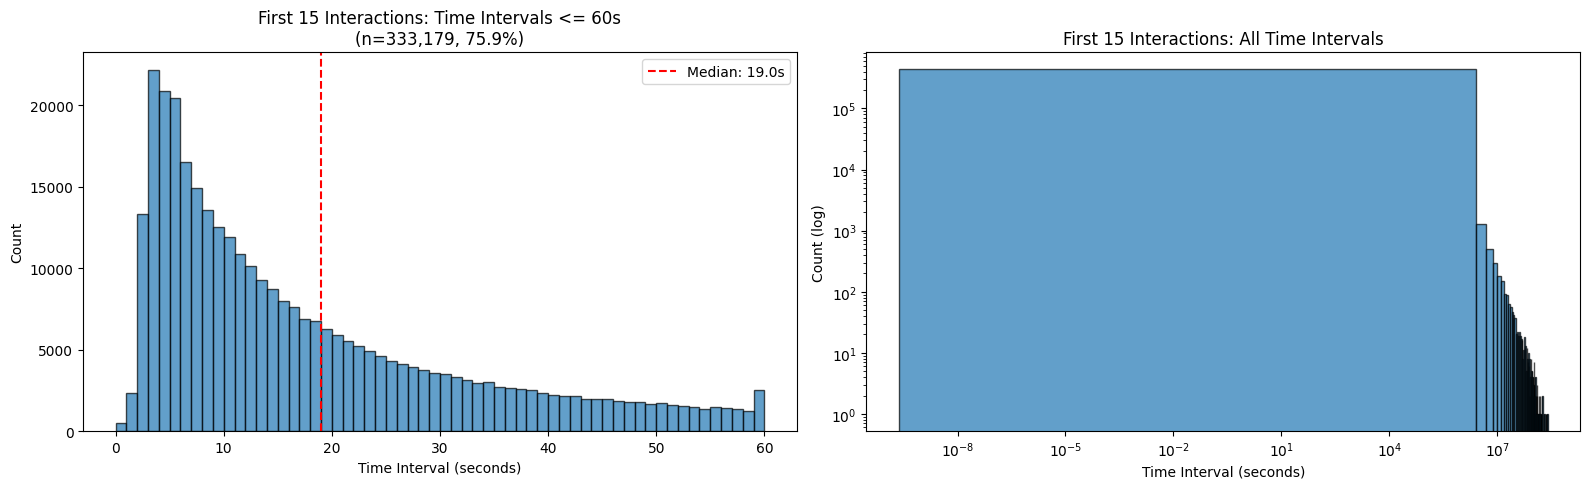

[첫 15개 상호작용 내 시간 간격 구간별 비율]
  5초 이하: 79,624개 (18.1%)
  10초 이하: 149,023개 (33.9%)
  30초 이하: 272,835개 (62.1%)
  1분 이하: 333,179개 (75.9%)
  5분 이하: 408,583개 (93.1%)
  1시간 이하: 425,092개 (96.8%)
  1시간 초과: 13,948개 (3.2%)


In [6]:
# 시간 간격 분포 시각화 (짧은 간격에 집중)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 60초 이하 구간 (부트스트래핑 의심 구간)
short_intervals = first_15_intervals[first_15_intervals <= 60]
axes[0].hist(short_intervals, bins=60, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Time Interval (seconds)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'First 15 Interactions: Time Intervals <= 60s\n(n={len(short_intervals):,}, {len(short_intervals)/len(first_15_intervals)*100:.1f}%)')
axes[0].axvline(first_15_intervals.median(), color='red', linestyle='--', label=f'Median: {first_15_intervals.median():.1f}s')
axes[0].legend()

# 전체 분포 (로그 스케일)
axes[1].hist(first_15_intervals, bins=100, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Time Interval (seconds)')
axes[1].set_ylabel('Count (log)')
axes[1].set_title('First 15 Interactions: All Time Intervals')
axes[1].set_yscale('log')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

# 구간별 비율
print("=" * 60)
print("[첫 15개 상호작용 내 시간 간격 구간별 비율]")
interval_bins = [
    ('5초 이하', first_15_intervals <= 5),
    ('10초 이하', first_15_intervals <= 10),
    ('30초 이하', first_15_intervals <= 30),
    ('1분 이하', first_15_intervals <= 60),
    ('5분 이하', first_15_intervals <= 300),
    ('1시간 이하', first_15_intervals <= 3600),
    ('1시간 초과', first_15_intervals > 3600),
]
for label, mask in interval_bins:
    count = mask.sum()
    pct = count / len(first_15_intervals) * 100
    print(f"  {label}: {count:,}개 ({pct:.1f}%)")

---
## 2. 첫 15개 vs 이후 상호작용의 시간 간격 비교

In [7]:
# 16번째 이후 시간 간격
after_15_intervals = after_15['time_diff'].dropna()

print("=" * 60)
print("[첫 15개 vs 16번째 이후 시간 간격 비교]")
print(f"\n{'구분':<20} {'평균(초)':<15} {'중앙값(초)':<15} {'N':<10}")
print("-" * 60)
print(f"{'첫 15개 내':<20} {first_15_intervals.mean():<15.1f} {first_15_intervals.median():<15.1f} {len(first_15_intervals):<10,}")
print(f"{'16번째 이후':<20} {after_15_intervals.mean():<15.1f} {after_15_intervals.median():<15.1f} {len(after_15_intervals):<10,}")

[첫 15개 vs 16번째 이후 시간 간격 비교]

구분                   평균(초)           중앙값(초)          N         
------------------------------------------------------------
첫 15개 내              124532.1        19.0            439,040   
16번째 이후              243104.1        18.0            4,684,071 


In [8]:
# 유저별 평균 시간 간격 비교
# 첫 15개 내 평균 간격
user_first15_avg_interval = first_15[first_15['seq_num'] > 1].groupby('user')['time_diff'].mean()
# 16번째 이후 평균 간격
user_after15_avg_interval = after_15.groupby('user')['time_diff'].mean()

# 둘 다 있는 유저만 비교
common_users = user_first15_avg_interval.index.intersection(user_after15_avg_interval.index)
print(f"비교 가능 유저 수: {len(common_users):,}명")

comparison_df = pd.DataFrame({
    'first_15_avg': user_first15_avg_interval[common_users],
    'after_15_avg': user_after15_avg_interval[common_users]
})
comparison_df['ratio'] = comparison_df['after_15_avg'] / comparison_df['first_15_avg']

print(f"\n첫 15개 내 평균 간격 중앙값: {comparison_df['first_15_avg'].median():.1f}초")
print(f"16번째 이후 평균 간격 중앙값: {comparison_df['after_15_avg'].median():.1f}초")
print(f"비율(이후/첫15개) 중앙값: {comparison_df['ratio'].median():.2f}배")

비교 가능 유저 수: 31,360명

첫 15개 내 평균 간격 중앙값: 48.6초
16번째 이후 평균 간격 중앙값: 7743.3초
비율(이후/첫15개) 중앙값: 22.69배


C:\Users\dynam\AppData\Local\Temp\ipykernel_9232\799441599.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_to_plot, labels=['First 15', 'After 15'], patch_artist=True)


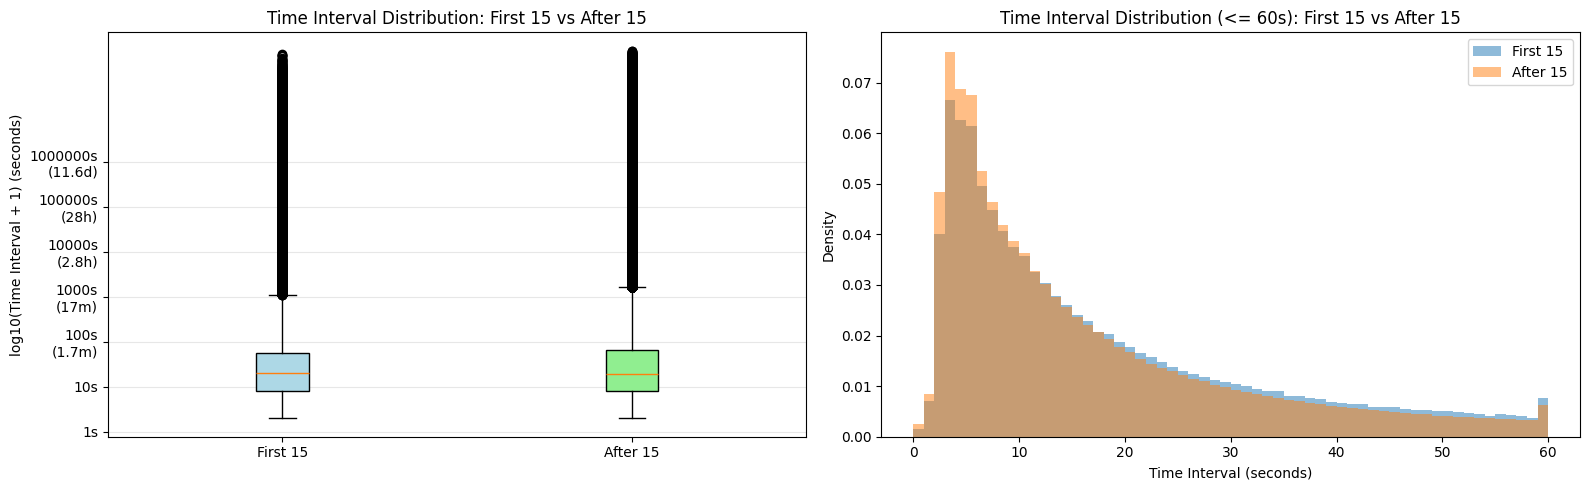

In [9]:
# 시각화: 첫 15개 vs 이후 시간 간격 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 박스플롯 (로그 스케일)
data_to_plot = [
    np.log10(first_15_intervals[first_15_intervals > 0] + 1),
    np.log10(after_15_intervals[after_15_intervals > 0] + 1)
]
bp = axes[0].boxplot(data_to_plot, labels=['First 15', 'After 15'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightgreen')
axes[0].set_ylabel('log10(Time Interval + 1) (seconds)')
axes[0].set_title('Time Interval Distribution: First 15 vs After 15')
axes[0].grid(axis='y', alpha=0.3)

# y축 눈금을 실제 시간으로 표시
yticks = [0, 1, 2, 3, 4, 5, 6]
yticklabels = ['1s', '10s', '100s\n(1.7m)', '1000s\n(17m)', '10000s\n(2.8h)', '100000s\n(28h)', '1000000s\n(11.6d)']
axes[0].set_yticks(yticks)
axes[0].set_yticklabels(yticklabels)

# 히스토그램 비교 (1분 이하 구간)
axes[1].hist(first_15_intervals[first_15_intervals <= 60], bins=60, alpha=0.5, label='First 15', density=True)
axes[1].hist(after_15_intervals[after_15_intervals <= 60], bins=60, alpha=0.5, label='After 15', density=True)
axes[1].set_xlabel('Time Interval (seconds)')
axes[1].set_ylabel('Density')
axes[1].set_title('Time Interval Distribution (<= 60s): First 15 vs After 15')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 3. 첫 15개 상호작용의 아이템 인기도 분석

In [10]:
# 첫 15개 vs 16번째 이후 아이템 인기도 순위 비교
first_15_ranks = first_15['item_rank']
after_15_ranks = after_15['item_rank']

print("=" * 60)
print("[아이템 인기도 순위 비교]")
print(f"\n{'구분':<20} {'평균 순위':<15} {'중앙값 순위':<15}")
print("-" * 50)
print(f"{'첫 15개':<20} {first_15_ranks.mean():<15.1f} {first_15_ranks.median():<15.1f}")
print(f"{'16번째 이후':<20} {after_15_ranks.mean():<15.1f} {after_15_ranks.median():<15.1f}")

[아이템 인기도 순위 비교]

구분                   평균 순위           중앙값 순위         
--------------------------------------------------
첫 15개                817.3           487.0          
16번째 이후              962.2           424.0          


In [11]:
# 인기도 순위 구간별 분포
print("=" * 60)
print("[인기도 순위 구간별 비율]")
print(f"\n{'구간':<20} {'첫 15개 (%)':<15} {'16번째 이후 (%)':<15}")
print("-" * 50)

rank_bins = [
    ('Top 50', 50),
    ('Top 100', 100),
    ('Top 150', 150),
    ('Top 200', 200),
    ('Top 500', 500),
    ('Top 1000', 1000),
]

for label, threshold in rank_bins:
    first15_pct = (first_15_ranks <= threshold).sum() / len(first_15_ranks) * 100
    after15_pct = (after_15_ranks <= threshold).sum() / len(after_15_ranks) * 100
    print(f"{label:<20} {first15_pct:<15.1f} {after15_pct:<15.1f}")

[인기도 순위 구간별 비율]

구간                   첫 15개 (%)       16번째 이후 (%)    
--------------------------------------------------
Top 50               19.3            12.3           
Top 100              26.0            21.3           
Top 150              31.0            28.1           
Top 200              34.7            33.6           
Top 500              50.7            53.8           
Top 1000             71.2            70.2           


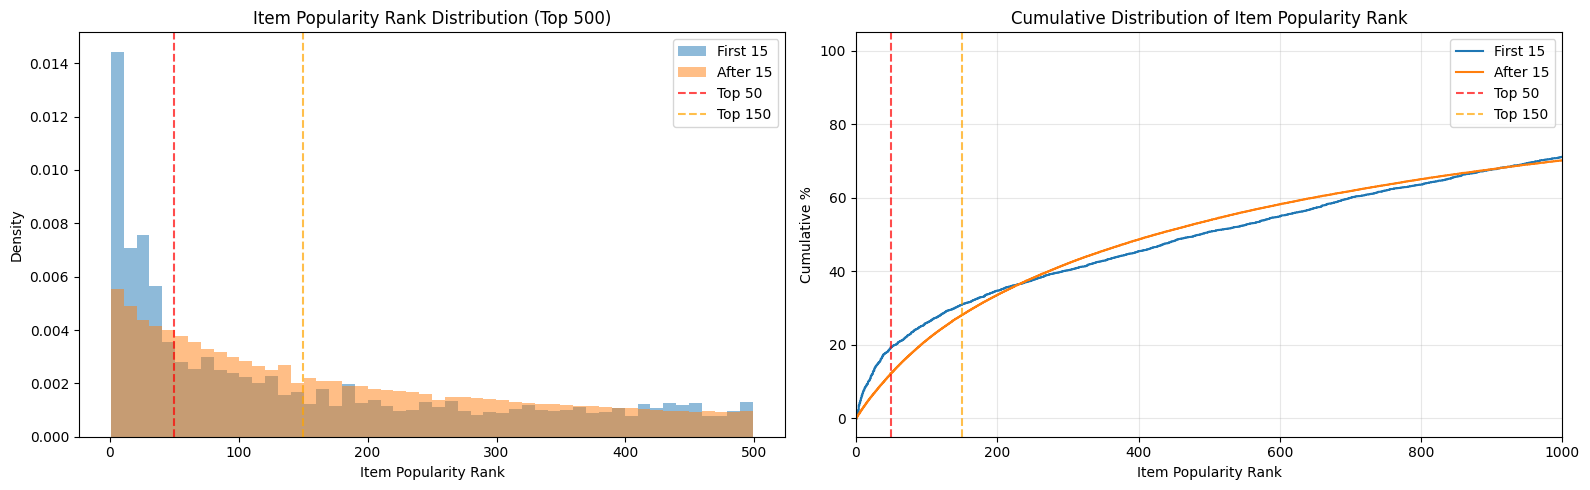

In [12]:
# 인기도 순위 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 히스토그램 (Top 500까지)
axes[0].hist(first_15_ranks[first_15_ranks <= 500], bins=50, alpha=0.5, label='First 15', density=True)
axes[0].hist(after_15_ranks[after_15_ranks <= 500], bins=50, alpha=0.5, label='After 15', density=True)
axes[0].axvline(50, color='red', linestyle='--', alpha=0.7, label='Top 50')
axes[0].axvline(150, color='orange', linestyle='--', alpha=0.7, label='Top 150')
axes[0].set_xlabel('Item Popularity Rank')
axes[0].set_ylabel('Density')
axes[0].set_title('Item Popularity Rank Distribution (Top 500)')
axes[0].legend()

# 누적 분포
first15_sorted = np.sort(first_15_ranks)
after15_sorted = np.sort(after_15_ranks)
axes[1].plot(first15_sorted, np.arange(1, len(first15_sorted)+1)/len(first15_sorted)*100, label='First 15')
axes[1].plot(after15_sorted, np.arange(1, len(after15_sorted)+1)/len(after15_sorted)*100, label='After 15')
axes[1].axvline(50, color='red', linestyle='--', alpha=0.7, label='Top 50')
axes[1].axvline(150, color='orange', linestyle='--', alpha=0.7, label='Top 150')
axes[1].set_xlabel('Item Popularity Rank')
axes[1].set_ylabel('Cumulative %')
axes[1].set_title('Cumulative Distribution of Item Popularity Rank')
axes[1].set_xlim(0, 1000)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Top 50~150 구간 (부트스트래핑에서 제외된 구간) 상세 분석
print("=" * 60)
print("[Top 50~150 구간 분석 (부트스트래핑에서 제외된 인기작)]")

first15_in_range = ((first_15_ranks > 50) & (first_15_ranks <= 150)).sum() / len(first_15_ranks) * 100
after15_in_range = ((after_15_ranks > 50) & (after_15_ranks <= 150)).sum() / len(after_15_ranks) * 100

print(f"첫 15개에서 51~150위 비율: {first15_in_range:.1f}%")
print(f"16번째 이후에서 51~150위 비율: {after15_in_range:.1f}%")

first15_top50 = (first_15_ranks <= 50).sum() / len(first_15_ranks) * 100
after15_top50 = (after_15_ranks <= 50).sum() / len(after_15_ranks) * 100

print(f"\n첫 15개에서 Top 50 비율: {first15_top50:.1f}%")
print(f"16번째 이후에서 Top 50 비율: {after15_top50:.1f}%")
print(f"\n→ 부트스트래핑에서 Top 50~150이 제외되었다면, 첫 15개에서 이 구간 비율이 낮아야 함")

[Top 50~150 구간 분석 (부트스트래핑에서 제외된 인기작)]
첫 15개에서 51~150위 비율: 11.6%
16번째 이후에서 51~150위 비율: 15.8%

첫 15개에서 Top 50 비율: 19.3%
16번째 이후에서 Top 50 비율: 12.3%

→ 부트스트래핑에서 Top 50~150이 제외되었다면, 첫 15개에서 이 구간 비율이 낮아야 함


---
## 4. 첫 15개 상호작용의 아이템 중복률 분석

In [14]:
# 첫 15개에 등장하는 아이템 분석
first_15_items = first_15['item'].values
first_15_item_counts = Counter(first_15_items)

total_users = ratings['user'].nunique()
total_first15_interactions = len(first_15)

print("=" * 60)
print("[첫 15개 상호작용 아이템 중복률]")
print(f"총 유저 수: {total_users:,}")
print(f"첫 15개 상호작용 수: {total_first15_interactions:,}")
print(f"첫 15개에 등장한 고유 아이템 수: {len(first_15_item_counts):,}")
print(f"전체 아이템 수: {ratings['item'].nunique():,}")
print(f"\n고유 아이템 / 전체 아이템: {len(first_15_item_counts)/ratings['item'].nunique()*100:.1f}%")

[첫 15개 상호작용 아이템 중복률]
총 유저 수: 31,360
첫 15개 상호작용 수: 470,400
첫 15개에 등장한 고유 아이템 수: 6,406
전체 아이템 수: 6,807

고유 아이템 / 전체 아이템: 94.1%


In [15]:
# 가장 많이 등장한 아이템 Top 30
top_30_first15_items = first_15_item_counts.most_common(30)

print("=" * 60)
print("[첫 15개에서 가장 많이 등장한 아이템 Top 30]")
print(f"{'순위':<6} {'아이템ID':<12} {'등장횟수':<12} {'유저비율(%)':<12} {'전체인기순위':<12}")
print("-" * 54)

for i, (item_id, count) in enumerate(top_30_first15_items, 1):
    user_pct = count / total_users * 100
    global_rank = item_rank[item_id]
    print(f"{i:<6} {item_id:<12} {count:<12,} {user_pct:<12.1f} {global_rank:<12.0f}")

[첫 15개에서 가장 많이 등장한 아이템 Top 30]
순위     아이템ID        등장횟수         유저비율(%)      전체인기순위      
------------------------------------------------------
1      318          6,253        19.9         4           
2      296          3,811        12.2         3           
3      2571         3,395        10.8         1           
4      7153         3,254        10.4         7           
5      2959         3,254        10.4         2           
6      356          3,144        10.0         5           
7      5952         3,120        9.9          8           
8      858          2,987        9.5          21          
9      58559        2,976        9.5          24          
10     4993         2,879        9.2          6           
11     527          2,810        9.0          26          
12     50           2,795        8.9          17          
13     593          2,742        8.7          9           
14     2858         2,467        7.9          10          
15     260          2,406    

In [16]:
# 첫 15개 vs 이후 아이템 집중도 비교
after_15_items = after_15['item'].values
after_15_item_counts = Counter(after_15_items)

# 상위 N개 아이템이 차지하는 비율
print("=" * 60)
print("[아이템 집중도 비교: 상위 N개 아이템이 차지하는 비율]")
print(f"\n{'Top N':<10} {'첫 15개 (%)':<15} {'16번째 이후 (%)':<15}")
print("-" * 40)

for top_n in [10, 50, 100, 200, 500]:
    first15_top_items = [item for item, _ in first_15_item_counts.most_common(top_n)]
    after15_top_items = [item for item, _ in after_15_item_counts.most_common(top_n)]
    
    first15_top_count = sum(first_15_item_counts[item] for item in first15_top_items)
    after15_top_count = sum(after_15_item_counts[item] for item in after15_top_items)
    
    first15_pct = first15_top_count / len(first_15_items) * 100
    after15_pct = after15_top_count / len(after_15_items) * 100
    
    print(f"{top_n:<10} {first15_pct:<15.1f} {after15_pct:<15.1f}")

[아이템 집중도 비교: 상위 N개 아이템이 차지하는 비율]

Top N      첫 15개 (%)       16번째 이후 (%)    
----------------------------------------
10         7.5             3.0            
50         20.4            12.4           
100        28.2            21.4           
200        38.9            33.6           
500        60.3            53.9           


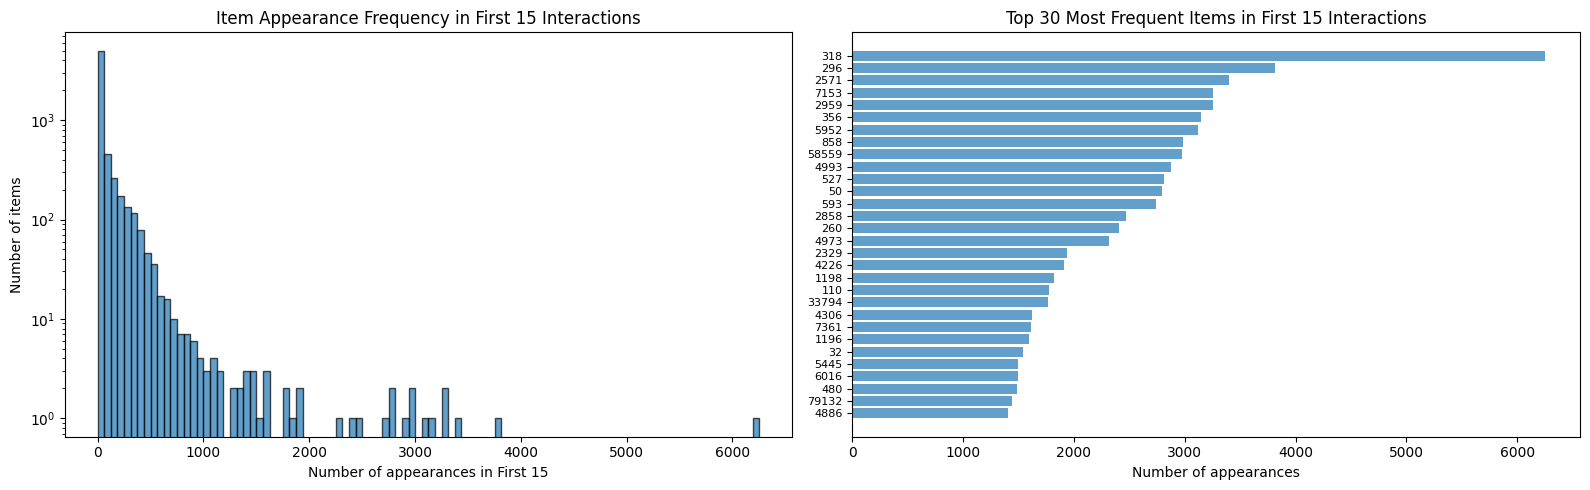

In [17]:
# 시각화: 아이템 등장 빈도 분포
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 첫 15개 아이템 등장 빈도 분포
first15_counts = list(first_15_item_counts.values())
axes[0].hist(first15_counts, bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of appearances in First 15')
axes[0].set_ylabel('Number of items')
axes[0].set_title('Item Appearance Frequency in First 15 Interactions')
axes[0].set_yscale('log')

# Top 30 아이템 바 차트
top_30_items = [str(item) for item, _ in top_30_first15_items]
top_30_counts = [count for _, count in top_30_first15_items]
axes[1].barh(range(len(top_30_items)), top_30_counts, alpha=0.7)
axes[1].set_yticks(range(len(top_30_items)))
axes[1].set_yticklabels(top_30_items, fontsize=8)
axes[1].set_xlabel('Number of appearances')
axes[1].set_title('Top 30 Most Frequent Items in First 15 Interactions')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

---
## 5. v3 vs v4 시기 유저 비교

In [18]:
# v4 시기 유저가 충분한지 확인
if len(v4_users) < 100:
    print(f"v4 시기 유저가 {len(v4_users)}명으로 너무 적어 비교 분석 생략")
else:
    # v3 유저의 첫 15개
    v3_first_15 = first_15[first_15['user'].isin(v3_users)]
    # v4 유저의 첫 15개
    v4_first_15 = first_15[first_15['user'].isin(v4_users)]
    
    print("=" * 60)
    print("[v3 vs v4 시기 유저 첫 15개 비교]")
    print(f"v3 유저 첫 15개 상호작용: {len(v3_first_15):,}개")
    print(f"v4 유저 첫 15개 상호작용: {len(v4_first_15):,}개")

[v3 vs v4 시기 유저 첫 15개 비교]
v3 유저 첫 15개 상호작용: 452,340개
v4 유저 첫 15개 상호작용: 18,060개



[시간 간격 비교]
v3 중앙값: 19.0초
v4 중앙값: 8.0초

[아이템 인기도 순위 비교]
v3 중앙값 순위: 510
v4 중앙값 순위: 62


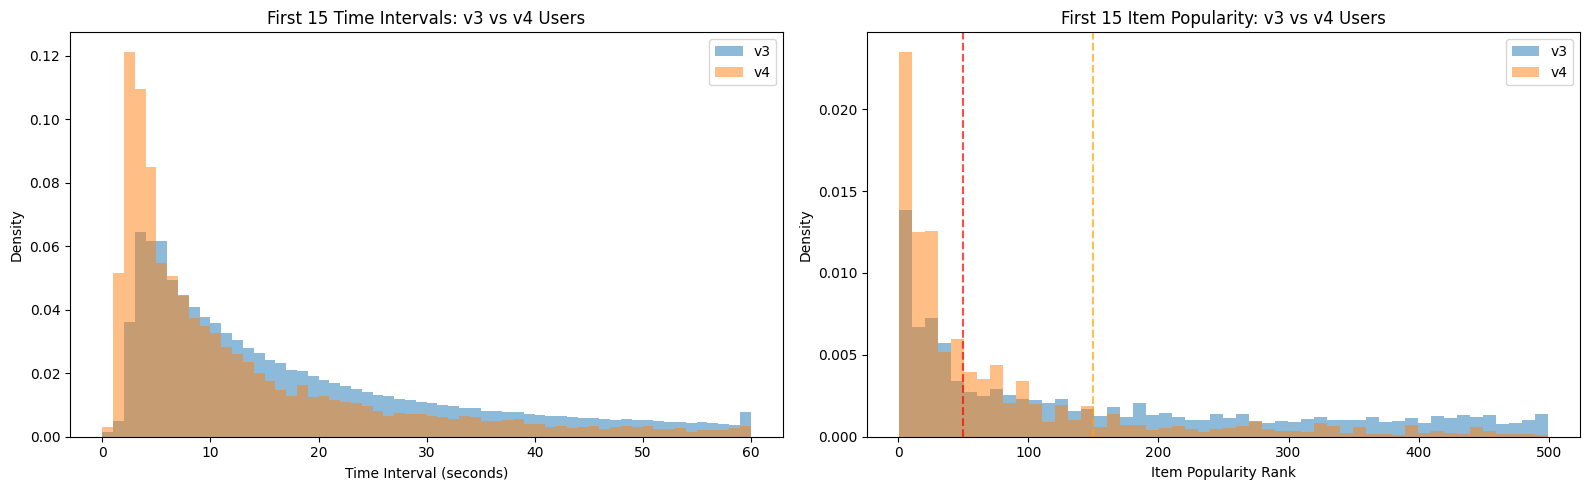

In [19]:
if len(v4_users) >= 100:
    # 시간 간격 비교
    v3_intervals = v3_first_15[v3_first_15['seq_num'] > 1]['time_diff'].dropna()
    v4_intervals = v4_first_15[v4_first_15['seq_num'] > 1]['time_diff'].dropna()
    
    print("\n[시간 간격 비교]")
    print(f"v3 중앙값: {v3_intervals.median():.1f}초")
    print(f"v4 중앙값: {v4_intervals.median():.1f}초")
    
    # 아이템 인기도 비교
    v3_ranks = v3_first_15['item_rank']
    v4_ranks = v4_first_15['item_rank']
    
    print("\n[아이템 인기도 순위 비교]")
    print(f"v3 중앙값 순위: {v3_ranks.median():.0f}")
    print(f"v4 중앙값 순위: {v4_ranks.median():.0f}")
    
    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # 시간 간격 비교
    axes[0].hist(v3_intervals[v3_intervals <= 60], bins=60, alpha=0.5, label='v3', density=True)
    axes[0].hist(v4_intervals[v4_intervals <= 60], bins=60, alpha=0.5, label='v4', density=True)
    axes[0].set_xlabel('Time Interval (seconds)')
    axes[0].set_ylabel('Density')
    axes[0].set_title('First 15 Time Intervals: v3 vs v4 Users')
    axes[0].legend()
    
    # 인기도 순위 비교
    axes[1].hist(v3_ranks[v3_ranks <= 500], bins=50, alpha=0.5, label='v3', density=True)
    axes[1].hist(v4_ranks[v4_ranks <= 500], bins=50, alpha=0.5, label='v4', density=True)
    axes[1].axvline(50, color='red', linestyle='--', alpha=0.7)
    axes[1].axvline(150, color='orange', linestyle='--', alpha=0.7)
    axes[1].set_xlabel('Item Popularity Rank')
    axes[1].set_ylabel('Density')
    axes[1].set_title('First 15 Item Popularity: v3 vs v4 Users')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

---
## 6. 요약

In [20]:
print("=" * 60)
print("[Step 2-3 부트스트래핑 패턴 분석 요약]")
print("=" * 60)

print("\n1. 첫 15개 상호작용 시간 간격")
print(f"   - 중앙값: {first_15_intervals.median():.1f}초")
print(f"   - 10초 이하 비율: {(first_15_intervals <= 10).sum()/len(first_15_intervals)*100:.1f}%")
print(f"   - 1분 이하 비율: {(first_15_intervals <= 60).sum()/len(first_15_intervals)*100:.1f}%")

print("\n2. 첫 15개 vs 이후 시간 간격")
print(f"   - 첫 15개 중앙값: {first_15_intervals.median():.1f}초")
print(f"   - 16번째 이후 중앙값: {after_15_intervals.median():.1f}초")
print(f"   - 비율(이후/첫15): {after_15_intervals.median()/first_15_intervals.median():.1f}배")

print("\n3. 아이템 인기도")
print(f"   - 첫 15개 Top 50 비율: {first15_top50:.1f}%")
print(f"   - 16번째 이후 Top 50 비율: {after15_top50:.1f}%")
print(f"   - 첫 15개 51~150위 비율: {first15_in_range:.1f}%")
print(f"   - 16번째 이후 51~150위 비율: {after15_in_range:.1f}%")

print("\n4. 아이템 중복률")
print(f"   - 첫 15개에 등장한 고유 아이템: {len(first_15_item_counts):,}개")
print(f"   - 가장 많이 등장한 아이템: {top_30_first15_items[0][0]} ({top_30_first15_items[0][1]:,}회, 유저의 {top_30_first15_items[0][1]/total_users*100:.1f}%)")

print("""
5. 결론
   - 시간 간격: 부트스트래핑 흔적 명확함
     → 첫 15개는 75.9%가 1분 이하 간격으로 입력됨
     → 유저별 평균 기준 첫 15개(48.6초) vs 이후(7,743초)로 22배 차이
     → 첫 15개는 한 세션에서 빠르게 입력된 "강제 평점"으로 판단
   
   - 아이템 인기도: 문서와 다른 패턴
     → Top 50이 첫 15개에서 오히려 더 높음 (19.3% vs 12.3%)
     → 현재 데이터 기준 인기도 순위 ≠ 당시 인기도 순위 가능성
     → 또는 v4 유저 포함으로 패턴 희석
   
   - 아이템 중복률: 높은 집중도 확인
     → 전체 6,807개 아이템 중 6,406개가 첫 15개에 등장 (94%)
     → 단, 특정 아이템(318)이 유저의 19.9%에게 등장 → 부트스트래핑 풀 존재 시사
   
   - 모델링 시사점:
     → 첫 15개 상호작용은 "자연스러운 선호"가 아닌 "시스템 유도 평점"
     → 시퀀스 모델에서 첫 N개 제외 또는 별도 처리 고려 필요""")

[Step 2-3 부트스트래핑 패턴 분석 요약]

1. 첫 15개 상호작용 시간 간격
   - 중앙값: 19.0초
   - 10초 이하 비율: 33.9%
   - 1분 이하 비율: 75.9%

2. 첫 15개 vs 이후 시간 간격
   - 첫 15개 중앙값: 19.0초
   - 16번째 이후 중앙값: 18.0초
   - 비율(이후/첫15): 0.9배

3. 아이템 인기도
   - 첫 15개 Top 50 비율: 19.3%
   - 16번째 이후 Top 50 비율: 12.3%
   - 첫 15개 51~150위 비율: 11.6%
   - 16번째 이후 51~150위 비율: 15.8%

4. 아이템 중복률
   - 첫 15개에 등장한 고유 아이템: 6,406개
   - 가장 많이 등장한 아이템: 318 (6,253회, 유저의 19.9%)

5. 결론
   - 시간 간격: 부트스트래핑 흔적 명확함
     → 첫 15개는 75.9%가 1분 이하 간격으로 입력됨
     → 유저별 평균 기준 첫 15개(48.6초) vs 이후(7,743초)로 22배 차이
     → 첫 15개는 한 세션에서 빠르게 입력된 "강제 평점"으로 판단

   - 아이템 인기도: 문서와 다른 패턴
     → Top 50이 첫 15개에서 오히려 더 높음 (19.3% vs 12.3%)
     → 현재 데이터 기준 인기도 순위 ≠ 당시 인기도 순위 가능성
     → 또는 v4 유저 포함으로 패턴 희석

   - 아이템 중복률: 높은 집중도 확인
     → 전체 6,807개 아이템 중 6,406개가 첫 15개에 등장 (94%)
     → 단, 특정 아이템(318)이 유저의 19.9%에게 등장 → 부트스트래핑 풀 존재 시사

   - 모델링 시사점:
     → 첫 15개 상호작용은 "자연스러운 선호"가 아닌 "시스템 유도 평점"
     → 시퀀스 모델에서 첫 N개 제외 또는 별도 처리 고려 필요
